<h1 style="text-align:center; color:#5DADE2;">🧙‍♂️ Hogwarts Sorting Hat AI</h1>

<p style="text-align:center; font-size:18px;">
"The Sorting Hat takes your traits into account..." 🎩
</p>

<hr>

<h2 style="color:#5DADE2;">Dataset Description</h2>

<p>
This dataset represents students from the wizarding world, described using personality traits, magical abilities, and background information.
The goal is to predict which Hogwarts house each student belongs to.
</p>

<p>
The dataset includes both <b>categorical features</b> (e.g., Blood Status) and <b>numerical features</b> (e.g., Bravery, Intelligence).
</p>

<h3 style="color:#5DADE2;">Features</h3>

<ul>
<li><b>Blood Status</b>  – Indicates the student's magical heritage (Pure-blood, Half-blood, Muggle-born)</li>

<li><b>Bravery</b>  – Measures courage and willingness to face danger</li>
<li><b>Intelligence</b>  – Reflects logical thinking and learning ability</li>
<li><b>Loyalty</b>  – Represents trustworthiness and dedication</li>
<li><b>Ambition</b>  – Indicates desire for success and leadership</li>

<li><b>Dark Arts Knowledge</b>  – Level of knowledge in dark magic</li>
<li><b>Quidditch Skills</b>  – Ability in playing Quidditch</li>
<li><b>Dueling Skills</b>  – Combat and spell-casting ability</li>
<li><b>Creativity</b>  – Measures imagination and originality</li>
</ul>

<h3 style="color:#5DADE2;">Target Variable</h3>

<p>
<b>House</b>: Gryffindor 🦁, Ravenclaw 🦅, Hufflepuff 🦡, or Slytherin 🐍
</p>


# <h2 style="color:#5DADE2;">Import Libraries</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, RobustScaler
from category_encoders import OneHotEncoder, BinaryEncoder, OrdinalEncoder
from sklearn.utils import resample
from sklearn.feature_selection import f_classif, chi2
from scipy.stats import spearmanr, chi2_contingency, pointbiserialr

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import pickle
import joblib   
import math
import warnings
warnings.filterwarnings('ignore')

# <h2 style="color:#5DADE2;">Data Overview</h2>

In [2]:
df=pd.read_csv(r"harry_potter_1000_students.csv")
df.shape

(1000, 10)

In [3]:
def data_info(data):

    """
    This function returns a DataFrame containing the summary information for each column
    """

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]


    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls})
    return info_df
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls
0,Blood Status,object,"[Half-blood, Pure-blood, Muggle-born]",3,0,0.0
1,Bravery,int64,"[7, 6, 2, 3, 1, 4, 5, 9, 10, 8]",10,0,0.0
2,Intelligence,int64,"[7, 3, 5, 6, 1, 4, 2, 9, 10, 8]",10,0,0.0
3,Loyalty,int64,"[7, 1, 6, 3, 5, 4, 2, 8, 10, 9]",10,0,0.0
4,Ambition,int64,"[7, 2, 5, 3, 4, 1, 6, 9, 10, 8]",10,0,0.0
5,Dark Arts Knowledge,int64,"[1, 4, 2, 3, 0, 5, 10, 7, 9, 8]",10,0,0.0
6,Quidditch Skills,int64,"[5, 7, 6, 9, 8, 4, 10, 3, 1, 0]",11,0,0.0
7,Dueling Skills,int64,"[7, 9, 10, 8, 3, 1, 4, 2, 5, 6]",10,0,0.0
8,Creativity,int64,"[7, 6, 2, 1, 5, 4, 3, 9, 10, 8]",10,0,0.0
9,House,object,"[Slytherin, Ravenclaw, Hufflepuff, Gryffindor]",4,0,0.0


In [4]:
df.describe().T.style.bar(subset=['mean'], color='#FFA07A').background_gradient(
    subset=['std', '50%', 'max'], cmap='Blues').set_properties(
        **{'font-size': '12pt', 'border': '1.5px solid black'}).set_caption("🔍 Summary Statistics of the Dataset")

,count,mean,std,min,25%,50%,75%,max
Bravery,1000.000000,5.026000,2.682633,1.000000,3.000000,5.000000,7.000000,10.000000
Intelligence,1000.000000,5.281000,2.661790,1.000000,3.000000,5.000000,7.000000,10.000000
Loyalty,1000.000000,5.129000,2.695111,1.000000,3.000000,5.000000,7.000000,10.000000
Ambition,1000.000000,5.136000,2.716041,1.000000,3.000000,5.000000,7.000000,10.000000
Dark Arts Knowledge,1000.000000,4.040000,3.112248,0.000000,1.000000,3.000000,7.000000,10.000000
Quidditch Skills,1000.000000,5.460000,2.748810,0.000000,4.000000,6.000000,7.000000,10.000000
Dueling Skills,1000.000000,6.223000,2.833249,1.000000,4.000000,7.000000,9.000000,10.000000
Creativity,1000.000000,5.208000,2.730969,1.000000,3.000000,5.000000,7.000000,10.000000


<div class="section fade">
<h2>Dataset Overview</h2>

<p>

- <b>Rows:</b> 1000  

- <b>Columns:</b> 10  

- <b>Target:</b> <b>House</b> (categorical)  

- <b>Features:</b> Numerical, scaled from 1 to 10  

- <b>Blood Status:</b> Dropped — not realistic  

</p>

<p>
The dataset is <b>balanced</b>: most features have <b>mean and median around 5</b>.  

It is clean: <b>no outliers, no null values, no duplicates</b>.
</p>

<p>
This ensures a smooth modeling process and reliable predictions for the Sorting Hat system.
</p>
</div>

In [5]:
df = df.drop("Blood Status", axis=1)

# <h2 style="color:#5DADE2;">Data Visualization</h2>


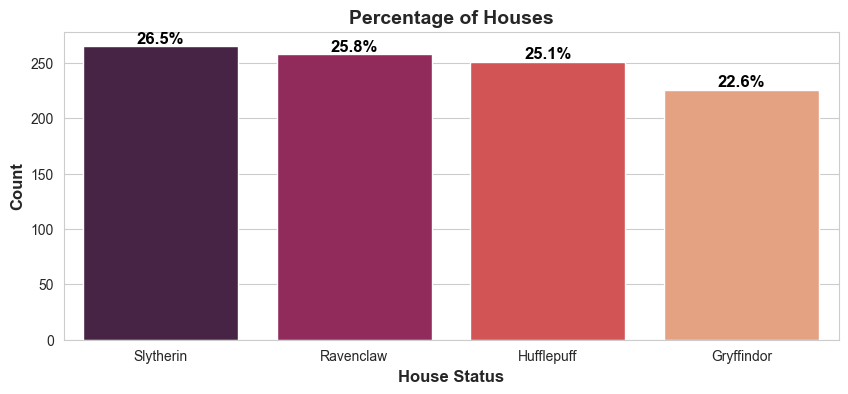

In [6]:
sns.set_style("whitegrid")
Houses = df["House"].value_counts(normalize=True)*100

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=Houses.index, y=df["House"].value_counts(), palette="rocket")

plt.title("Percentage of Houses", fontsize=14, fontweight='bold')
plt.xlabel("House Status", fontsize=12, fontweight='bold')
plt.ylabel("Count", fontsize=12, fontweight='bold')

for p, percentage in zip(ax.patches, Houses.values):
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black')
plt.show()

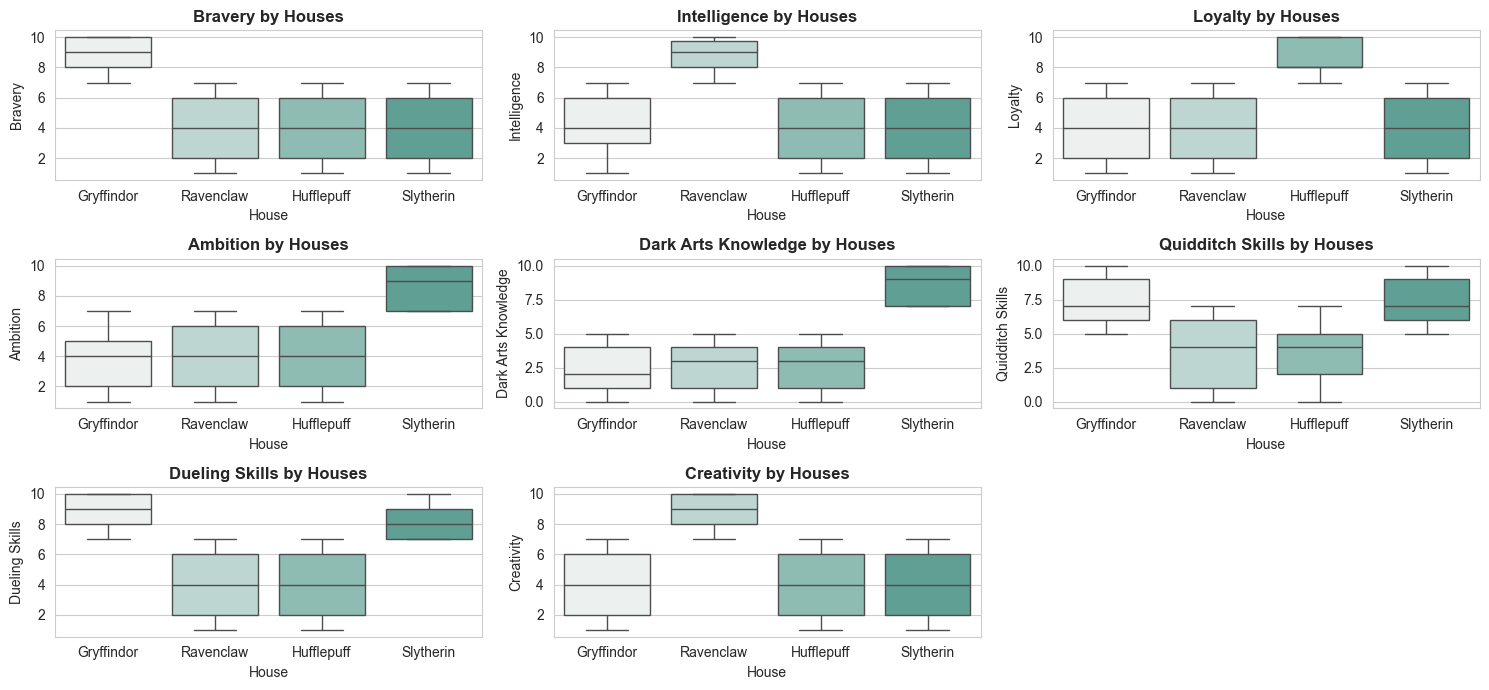

In [7]:
num =["Bravery","Intelligence","Loyalty","Ambition","Dark Arts Knowledge","Quidditch Skills","Dueling Skills","Creativity"]

fig, axes = plt.subplots(3, 3, figsize=(15, 7))
axes = axes.flatten()

for i, col in enumerate(num):
    sns.boxplot(
        x="House",
        y=col,
        data=df,
        ax=axes[i],
        palette="light:#5A9"
    )
    axes[i].set_title(f"{col} by Houses", fontweight="bold")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

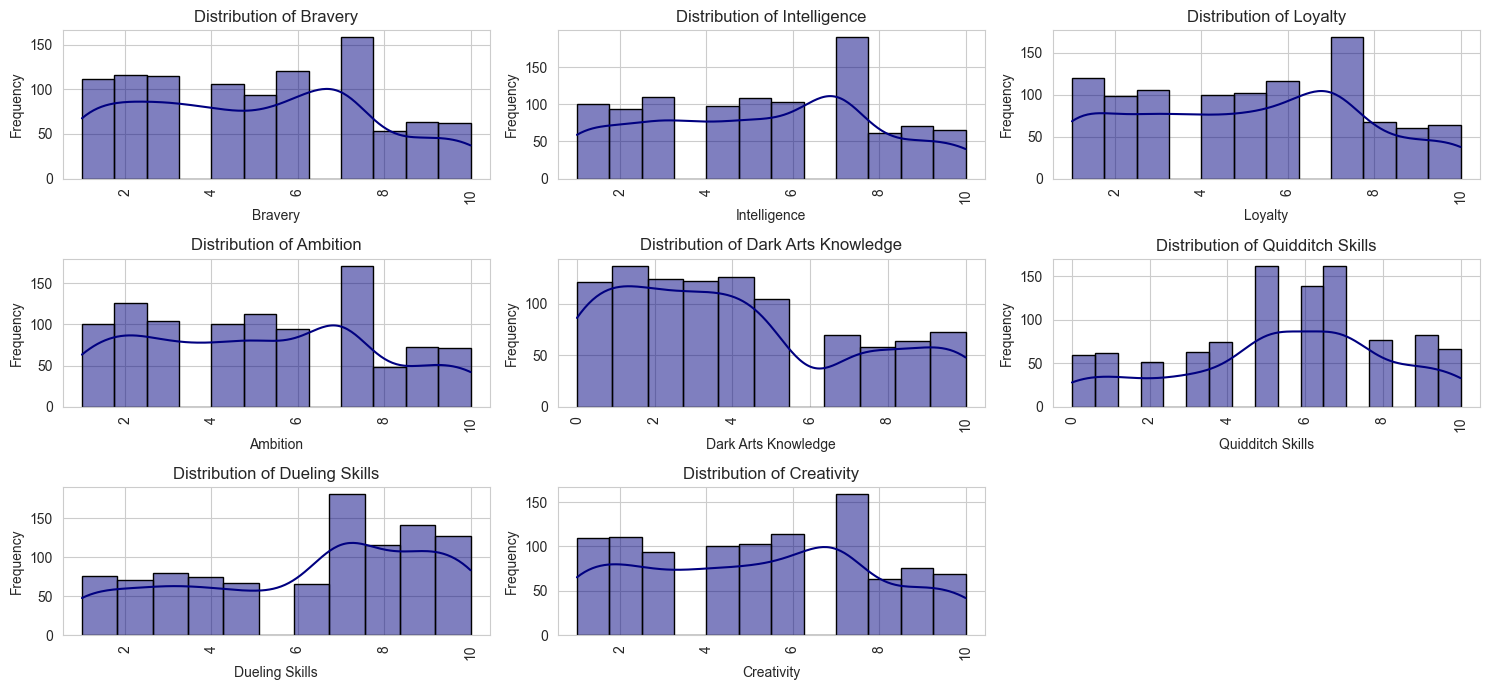

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(num) :
    sns.histplot(data=df, x=col, ax=axes[i], kde=True, color="navy", edgecolor="black")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis='x', rotation=90)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

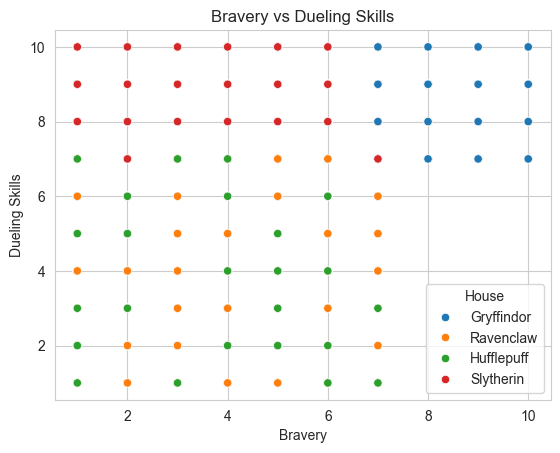

In [9]:
sns.scatterplot(x="Bravery", y="Dueling Skills", hue="House", data=df)
plt.title("Bravery vs Dueling Skills")
plt.show()

<div class="section fade">
<h2>House Feature Mapping</h2>

<p>
Each Hogwarts House tends to favor certain traits. The Sorting Hat system uses the following feature mapping:
</p>

<ul>
<li><b>Gryffindor:</b> Bravery, Dueling Skills, Quidditch Skills</li>
<li><b>Ravenclaw:</b> Intelligence, Creativity</li>
<li><b>Hufflepuff:</b> Loyalty</li>
<li><b>Slytherin:</b> Ambition, Dark Arts Knowledge, Quidditch Skills, Dueling Skills</li>
</ul>

<p>
<b>Interpretation:</b> If a student's value in a feature increases, it tends to favor the house(s) associated with that feature.  
For example:
<ul>
<li>High Bravery → more likely Gryffindor</li>
<li>High Intelligence → more likely Ravenclaw</li>
<li>High Loyalty → more likely Hufflepuff</li>
<li>High Ambition → more likely Slytherin</li>
<li>High Dueling Skills or Quidditch Skills → could influence either Gryffindor or Slytherin depending on other traits</li>
</ul>
</p>

<p>
This mapping helps visualize how different traits affect the house prediction and can guide feature importance analysis.
</p>
</div>


# <h2 style="color:#5DADE2;">Train-Test Split</h2>


In [10]:
X=df.drop(["House"],axis=1)
y=df["House"]

x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

# <h2 style="color:#5DADE2;">Encoding</h2>


In [11]:
label_encoding = LabelEncoder()
y_train = label_encoding.fit_transform(y_train)
y_test = label_encoding.transform(y_test)

label_mapping = dict(zip(label_encoding.classes_, label_encoding.transform(label_encoding.classes_)))
print("House label encoding mapping:", label_mapping)

House label encoding mapping: {'Gryffindor': np.int64(0), 'Hufflepuff': np.int64(1), 'Ravenclaw': np.int64(2), 'Slytherin': np.int64(3)}


# <h2 style="color:#5DADE2;">Correlation Analysis</h2>


In [12]:
x = x_train[num]
y = y_train
f_values, p_values = f_classif(x, y)
anova_df = pd.DataFrame({
    'Feature': num,
    'F-Score': f_values,
    'P-Value': p_values
}).sort_values(by='F-Score', ascending=False)

print(anova_df)

               Feature     F-Score        P-Value
4  Dark Arts Knowledge  744.153781  1.266045e-216
6       Dueling Skills  475.987370  4.156630e-168
3             Ambition  325.363664  5.506025e-132
0              Bravery  273.436520  3.196464e-117
7           Creativity  267.793031  1.583381e-115
1         Intelligence  266.100598  5.147531e-115
2              Loyalty  246.145373  7.639536e-109
5     Quidditch Skills  181.232063   7.940173e-87


# <h2 style="color:#5DADE2;">Model Training</h2>


In [13]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)
best_log_reg = grid_search.best_estimator_

y_pred = best_log_reg.predict(x_test)
y_pred_train = best_log_reg.predict(x_train)

print("Best Parameters:", grid_search.best_params_)
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 0.01, 'class_weight': None, 'penalty': 'l2'}
Train Accuracy: 1.0
Test Accuracy: 0.99


In [14]:
log_reg_final=LogisticRegression(C=10, class_weight=None, penalty='l2', max_iter=1000, random_state=42)
log_reg_final.fit(x_train, y_train)

y_pred_final = log_reg_final.predict(x_test)
y_pred_train_final = log_reg_final.predict(x_train)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train_final))
print("Test Accuracy:", accuracy_score(y_test, y_pred_final))

print(classification_report(y_test, y_pred_final, target_names=label_encoding.classes_))

Train Accuracy: 1.0
Test Accuracy: 0.99
              precision    recall  f1-score   support

  Gryffindor       0.98      1.00      0.99        65
  Hufflepuff       0.99      0.97      0.98        78
   Ravenclaw       0.99      0.99      0.99        84
   Slytherin       1.00      1.00      1.00        73

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



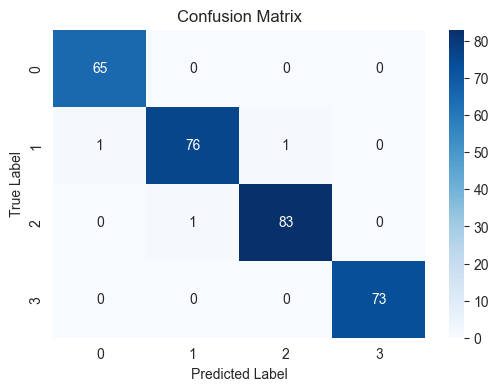

In [15]:
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# <h2 style="color:#5DADE2;">Save Model</h2>


In [16]:
with open("hogwarts_model.pkl", "wb") as f:
    pickle.dump(log_reg_final, f)

In [17]:
with open("hogwarts_encoder.pkl", "wb") as f:
    pickle.dump(label_encoding, f)